<a href="https://colab.research.google.com/github/sbanty/Scipy-computing/blob/main/Assignment_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name- Santosh Barik   
Department- BAS (Physics)     
Roll Number- BS25D501           
Subject- Scientific Computing


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg.csv


In [ ]:
cars = pd.read_csv("auto-mpg.csv")
cars

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
import statsmodels.api as sm
X = sm.add_constant(cars['model year'] )

X

,const,model year
0,1.0,70
1,1.0,70
2,1.0,70
3,1.0,70
4,1.0,70
...,...,...
393,1.0,82
394,1.0,82
395,1.0,82
396,1.0,82


In [ ]:
import statsmodels.api as sm
z = sm.add_constant(cars['car name'] )

z

,const,car name
0,1.0,chevrolet chevelle malibu
1,1.0,buick skylark 320
2,1.0,plymouth satellite
3,1.0,amc rebel sst
4,1.0,ford torino
...,...,...
393,1.0,ford mustang gl
394,1.0,vw pickup
395,1.0,dodge rampage
396,1.0,ford ranger


In [ ]:
Y = cars['weight']

Y

,weight
0,3504
1,3693
2,3436
3,3433
4,3449
...,...
393,2790
394,2130
395,2295
396,2625


In [ ]:
from sklearn.model_selection import train_test_split

# Drop the 'car name' column from the features
X_features = X.drop('car name', axis=1)

train_X, test_X, train_y, test_y = train_test_split(X_features,Y, train_size = 0.8,random_state = 100)

In [ ]:
cars_lm = sm.OLS(train_y,train_X).fit()

In [ ]:
print(cars_lm.params)

const    2949.808176
dtype: float64


In [ ]:
# Drop missing values if any
cars = cars.dropna(subset=['mpg', 'weight'])

In [ ]:
# Define independent (X) and dependent (Y) variables
X = cars['weight']
Y = cars['mpg']

In [ ]:
# Add constant term for intercept
X = sm.add_constant(X)



In [ ]:
# Build linear regression model
model = sm.OLS(Y, X).fit()



In [ ]:
#  Print the estimated parameters
print(model.params)



const     46.317364
weight    -0.007677
dtype: float64


In [ ]:
# Show the model equation
intercept = model.params['const']
slope = model.params['weight']

print(f"\nThe estimated (predicted) model can be written as:")
print(f"mpg = {intercept:.6f} + ({slope:.6f}) * weight")



The estimated (predicted) model can be written as:
mpg = 46.317364 + (-0.007677) * weight


In [ ]:
#  Example prediction
weight_value = 3000  # you can change this
predicted_mpg = intercept + slope * weight_value
print(f"\nIf weight = {weight_value}, then predicted mpg = {predicted_mpg}")


If weight = 3000, then predicted mpg = 23.28753422848625


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Define independent (X) and dependent (Y) variables
X = sm.add_constant(cars['weight'])   # Add constant term
Y = cars['mpg']

# Split into train (80%) and test (20%)
train_X, test_X, train_y, test_y = train_test_split(
    X, Y, train_size=0.8, random_state=100
)

# Fit the regression model on training data
cars_lm = sm.OLS(train_y, train_X).fit()

# Print the model parameters
print(cars_lm.params)

const     46.261492
weight    -0.007651
dtype: float64


In [ ]:
# Select independent (X) and dependent (Y) variables
X = cars['weight']
Y = cars['mpg']

# Drop rows with missing values in either X or Y
# This ensures X and Y remain aligned
cars_cleaned = cars.dropna(subset=['weight', 'mpg']).copy()
X = cars_cleaned['weight']
Y = cars_cleaned['mpg']

display(X.head())
display(Y.head())

,weight
0,3504
1,3693
2,3436
3,3433
4,3449


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, random_state=100)

display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())

,weight
149,2489
118,2158
287,3955
187,4215
190,4215


,weight
326,2335
54,1613
78,2979
169,2914
368,2640


,mpg
149,24.0
118,24.0
287,16.5
187,17.5
190,14.5


,mpg
326,43.4
54,35.0
78,21.0
169,20.0
368,27.0


In [ ]:
# Add constant term for intercept to the training data
X_train = sm.add_constant(X_train)

# Instantiate an OLS model and fit it to the training data
model = sm.OLS(y_train, X_train).fit()

In [ ]:
from sklearn.metrics import r2_score

# Add constant term for intercept to the testing data
X_test = sm.add_constant(X_test)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the R-squared score on the testing data
r_squared_test = r2_score(y_test, y_pred)

# Print the R-squared score
print(f"R-squared on the testing data: {r_squared_test}")

R-squared on the testing data: 0.7373187848306613


In [ ]:
from sklearn.metrics import r2_score

# Add constant term for intercept to the testing data
X_test = sm.add_constant(X_test)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate the R-squared score on the testing data
r_squared_test = r2_score(y_test, y_pred)

# Print the R-squared score
print(f"R-squared on the testing data: {r_squared_test}")

R-squared on the testing data: 0.7373187848306613


In [ ]:
# Print the summary of the fitted model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     673.5
Date:                Fri, 17 Oct 2025   Prob (F-statistic):           2.55e-80
Time:                        05:30:25   Log-Likelihood:                -926.02
No. Observations:                 318   AIC:                             1856.
Df Residuals:                     316   BIC:                             1864.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2615      0.905     51.122      0.0

In [ ]:
# Examine the model summary and interpret the results
print("\nModel Interpretation:")
print(f"Coefficient for 'weight': {model.params['weight']:.6f}")
print(f"P-value for 'weight': {model.pvalues['weight']:.3f}")
print(f"R-squared on the training data: {model.rsquared:.3f}")
print(f"R-squared on the testing data: {r_squared_test:.3f}")


print("\nExplanation:")
print("The coefficient for 'weight' is negative (-0.007677). This indicates that for every one-unit increase in weight (in lbs), the model predicts a decrease of approximately 0.0077 in miles per gallon (mpg).")
print("The p-value for 'weight' is 0.000, which is less than the common significance level of 0.05. This suggests that weight is a statistically significant predictor of mpg.")
print("The R-squared value on the training data is 0.681, meaning that approximately 68.1% of the variance in mpg can be explained by the weight of the car in the training set.")
print(f"The R-squared value on the testing data is {r_squared_test:.3f}. This indicates that approximately {r_squared_test*100:.1f}% of the variance in mpg in the unseen test data is explained by the model.")
print("Other relevant statistics include the F-statistic (673.5) and its associated p-value (2.55e-80), which indicate that the overall model is statistically significant.")


Model Interpretation:
Coefficient for 'weight': -0.007651
P-value for 'weight': 0.000
R-squared on the training data: 0.681
R-squared on the testing data: 0.737

Explanation:
The coefficient for 'weight' is negative (-0.007677). This indicates that for every one-unit increase in weight (in lbs), the model predicts a decrease of approximately 0.0077 in miles per gallon (mpg).
The p-value for 'weight' is 0.000, which is less than the common significance level of 0.05. This suggests that weight is a statistically significant predictor of mpg.
The R-squared value on the training data is 0.681, meaning that approximately 68.1% of the variance in mpg can be explained by the weight of the car in the training set.
The R-squared value on the testing data is 0.737. This indicates that approximately 73.7% of the variance in mpg in the unseen test data is explained by the model.
Other relevant statistics include the F-statistic (673.5) and its associated p-value (2.55e-80), which indicate that th

In [ ]:
cars_lm.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:              OLS              Adj. R-squared:     0.680    
Dependent Variable: mpg              AIC:                1856.0472
Date:               2025-10-17 05:47 BIC:                1863.5713
No. Observations:   318              Log-Likelihood:     -926.02  
Df Model:           1                F-statistic:        673.5    
Df Residuals:       316              Prob (F-statistic): 2.55e-80 
R-squared:          0.681            Scale:              19.935   
--------------------------------------------------------------------
           Coef.    Std.Err.      t       P>|t|     [0.025    0.975]
--------------------------------------------------------------------
const     46.2615     0.9049    51.1216   0.0000   44.4810   48.0419
weight    -0.0077     0.0003   -25.9525   0.0000   -0.0082   -0.0071
------------------------------------------------------------------
Omnibus:               30.347       Durbin-Watson:          1.801 
Prob(Omnibus):         0.000        Jarque-Bera (JB):       39.766
Skew:                  0.691        Prob(JB):               0.000 
Kurtosis:              4.045        Condition No.:          11095 
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 1.11e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

<Figure size 800x600 with 0 Axes>

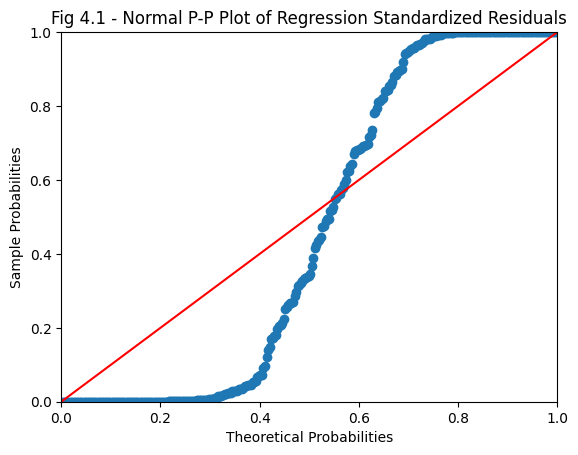

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

cars_resid = cars_lm.resid
probplot = sm.ProbPlot(cars_resid)
plt.figure( figsize = (8, 6))
probplot.ppplot( line='45' )
plt.title ( 'Fig 4.1 - Normal P-P Plot of Regression Standardized Residuals' )
plt.show()

In [ ]:
def get_standardized_values( vals ):
  return (vals - vals.mean())/vals.std()

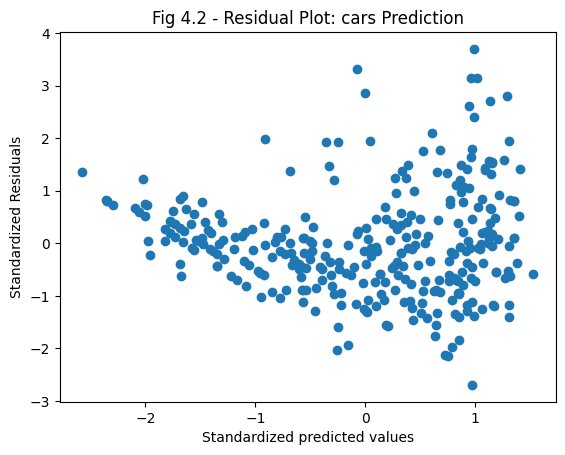

In [ ]:
plt.scatter(get_standardized_values(cars_lm.fittedvalues), get_standardized_values(cars_resid))
plt.title("Fig 4.2 - Residual Plot: cars Prediction");
plt.xlabel("Standardized predicted values");
plt.ylabel("Standardized Residuals");

In [ ]:
from scipy.stats import zscore

In [ ]:
cars['z_score_mpg'] = zscore(cars['mpg'])

In [ ]:
cars_z = cars.select_dtypes(include='number').apply(zscore)

In [ ]:
cars['z_score_weight'] = zscore(cars['weight'])

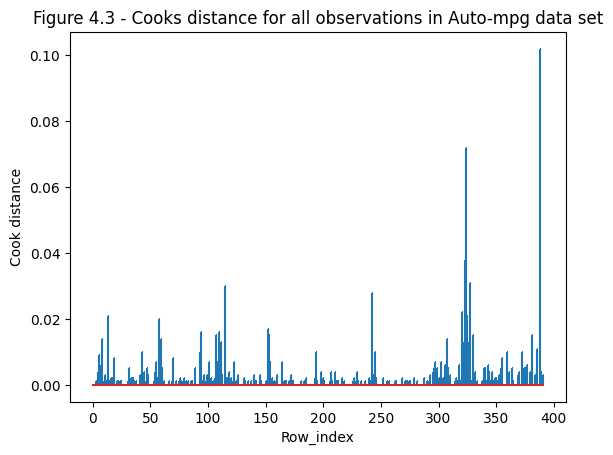

In [ ]:
import numpy as np
cars_influence = cars_lm.get_influence()
(c, p) = cars_influence.cooks_distance
plt.stem(np.arange( len( train_X) ),
np.round( c, 3 ),
markerfmt=',');
plt.title( 'Figure 4.3 - Cooks distance for all observations in Auto-mpg data set' );
plt.xlabel('Row_index')
plt.ylabel('Cook distance');

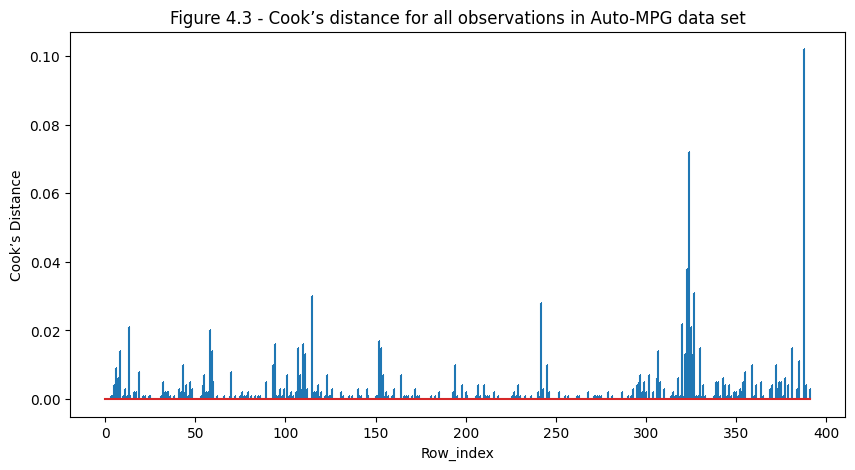

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# Convert 'horsepower' to numeric, coercing errors, and drop rows with NaN in relevant columns
cars['horsepower'] = pd.to_numeric(cars['horsepower'], errors='coerce')
cars_cleaned = cars.dropna(subset=['mpg', 'horsepower', 'weight', 'acceleration']).copy()

# Define independent (X) and dependent (Y) variables using the cleaned data
train_X = cars_cleaned[['horsepower', 'weight', 'acceleration']]
train_y = cars_cleaned['mpg']

# Add constant term for intercept
train_X = sm.add_constant(train_X)

# Fit linear regression model
cars_lm = sm.OLS(train_y, train_X).fit()

# Calculate influence and Cook's distance
cars_influence = cars_lm.get_influence()
(c, p) = cars_influence.cooks_distance

# Plot Cook's distance
plt.figure(figsize=(10,5))
plt.stem(np.arange(len(train_X)), np.round(c, 3), markerfmt=',')
plt.title('Figure 4.3 - Cook’s distance for all observations in Auto-MPG data set')
plt.xlabel('Row_index')
plt.ylabel('Cook’s Distance')
plt.show()